# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [34]:
# 📌 Import necessary libraries for data handling and visualization
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns  # Advanced visualizations

# 📌 Import libraries for machine learning and model evaluation
from sklearn.model_selection import train_test_split  # Splitting data into training and test sets
from sklearn.preprocessing import LabelEncoder  # Encoding categorical variables (party names)
from sklearn.tree import DecisionTreeClassifier  # Decision Tree model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Ensemble models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Model evaluation metrics


# 📌 Dictionary for the party colors, gracefully stolen from Kristian Dashnaw (Github.com/Dogmeat2000)

party_colors = {
    "Socialdemokratiet": "#b32722",
    "Radikale Venstre": "#713280",
    "Det Konservative Folkeparti": "#9eba27",
    "Nye Borgerlige": "#054f5c",
    "Socialistisk Folkeparti": "#dd0878",
    "Liberal Alliance": "#21c6cf",
    "Kristendemokraterne": "#bababa",
    "Moderaterne": "#6c39e5",
    "Dansk Folkeparti": "#f3cd41",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#00e66a",
    "Venstre": "#006697",
    "Danmarksdemokraterne": "#8ac3ff",
    "Enhedslisten": "#ed8019",
    "Alternativet": "#2a8f39",
    "Løsgænger": "#8c564b"
}

C:\Users\DooMz\AppData\Local\Temp\ipykernel_35892\3067720798.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_age_data, x='alder', y='parti', orient='h', palette=party_colors)


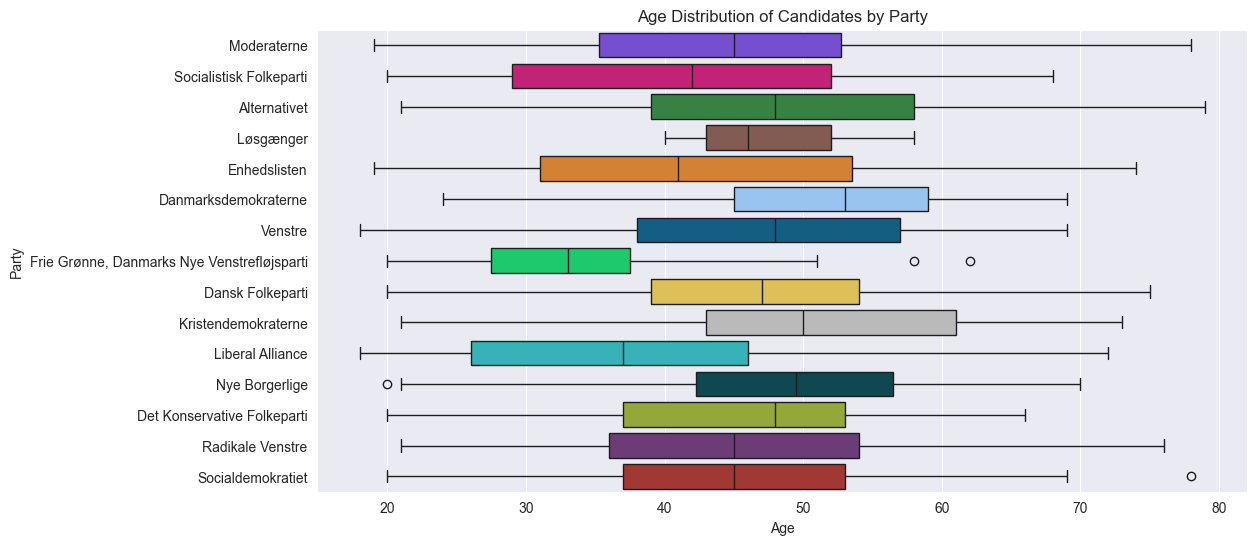

In [35]:
# 📌 Load the dataset from an Excel file
# Make sure the file path is correct before running the code
alldata = pd.read_excel("alldata.xlsx")  

# 📌 Remove candidates who are 17 years old or younger
# This ensures only eligible voters/candidates are considered in the analysis
filtered_alldata = alldata[alldata['alder'] > 17].copy()

# 📌 Select only the relevant columns: 'alder' (age) and 'parti' (political party)
# Drop any missing values to avoid errors in visualization
filtered_age_data = filtered_alldata[['alder', 'parti']].dropna()

# 📌 Set the figure size to ensure better readability of the plot
plt.figure(figsize=(12, 6))

# 📌 Create a boxplot to visualize the age distribution across different political parties
# - 'data' specifies the dataset to use
# - 'x' (horizontal axis) represents candidate ages
# - 'y' (vertical axis) represents the political party
# - 'orient' is set to 'h' (horizontal) to make the plot easier to read
# - 'palette' applies specific colors to each party for better distinction
sns.boxplot(data=filtered_age_data, x='alder', y='parti', orient='h', palette=party_colors)

# 📌 Add labels and title to the plot for clarity
plt.xlabel("Age")  # Label for the x-axis
plt.ylabel("Party")  # Label for the y-axis
plt.title("Age Distribution of Candidates by Party")  # Title of the plot

# 📌 Display the final boxplot
plt.show()


In [36]:
# 📌 Identify response columns (Exclude metadata like 'parti', 'alder', and 'navn')
# - We only keep numerical columns that represent candidate responses to questions
response_cols = filtered_alldata.drop(columns=['parti', 'alder', 'navn'], errors='ignore').select_dtypes(include=['number']).columns

# 📌 Calculate confidence score for each candidate
# - A confidence score is defined as the **percentage of extreme responses (-2 or 2)**
# - This helps us identify candidates with the strongest opinions
filtered_alldata['confidence_score'] = (filtered_alldata[response_cols].isin([-2, 2])).mean(axis=1)

# 📌 Retrieve the top 10 most confident candidates
# - Sorts candidates by confidence score in descending order
# - Selects only the top 10 candidates
top_confident_candidates = filtered_alldata[['navn', 'parti', 'alder', 'confidence_score']].sort_values(
    by='confidence_score', ascending=False).head(10)

# 📌 Force pandas to display the table in one row (prevent text wrapping)
pd.set_option("display.max_colwidth", None)  # Ensures full text is displayed
pd.set_option("display.expand_frame_repr", False)  # Prevents automatic wrapping into multiple rows

# 📌 Display the top confident candidates in a table format
print("Top 10 Most Confident Candidates:")
print(top_confident_candidates)


Top 10 Most Confident Candidates:
                    navn                                        parti  alder  confidence_score
505         Sarah Nørris                                 Enhedslisten     43          1.000000
88         Søren Vanting                  Det Konservative Folkeparti     50          1.000000
559  Kim Andkjær Doberck                               Nye Borgerlige     43          0.897959
152           Rashid Ali  Frie Grønne, Danmarks Nye Venstrefløjsparti     38          0.877551
44     Mohamed Abdikarim  Frie Grønne, Danmarks Nye Venstrefløjsparti     33          0.877551
437  Lone Vase Langballe                             Dansk Folkeparti     52          0.857143
503          Jan Filbært                                 Enhedslisten     57          0.857143
359       Frank Sørensen                             Dansk Folkeparti     58          0.857143
151     Elise Bjerkrheim  Frie Grønne, Danmarks Nye Venstrefløjsparti     48          0.857143
284           Jo

C:\Users\DooMz\AppData\Local\Temp\ipykernel_35892\196012995.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_alldata, x='parti', y=filtered_alldata[response_cols].std(axis=1), palette=party_colors)


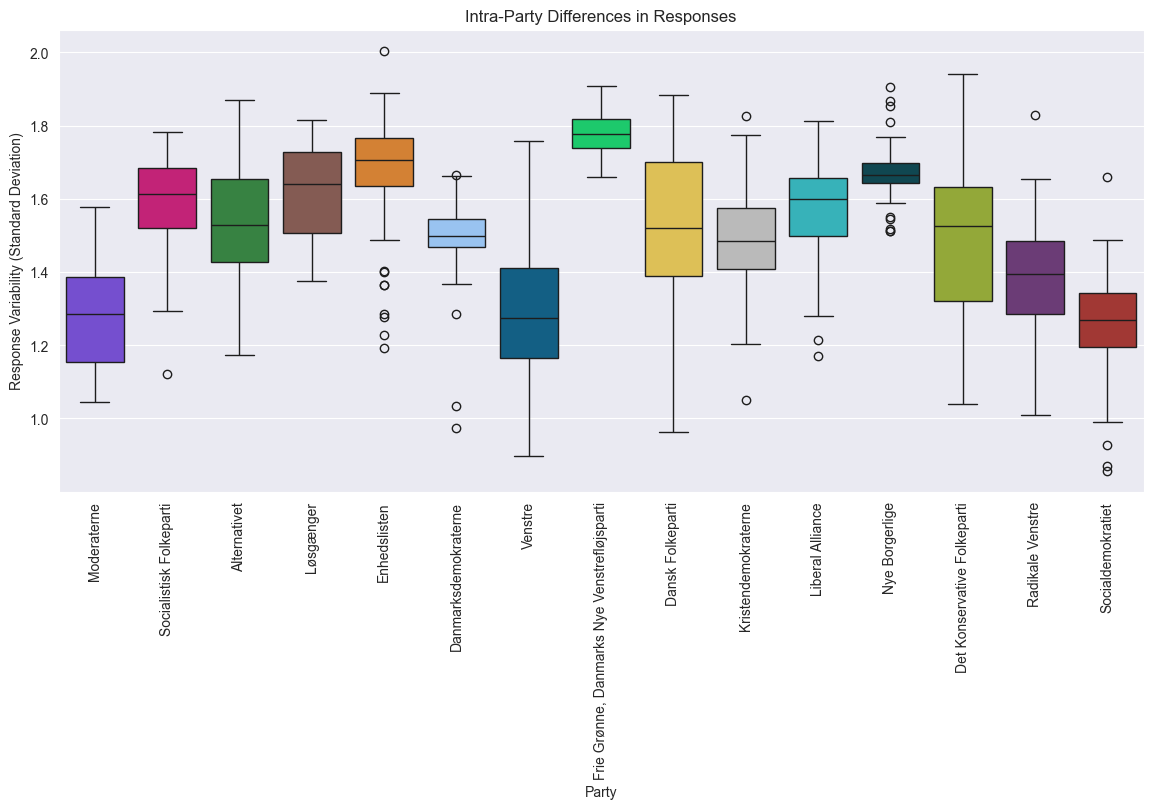

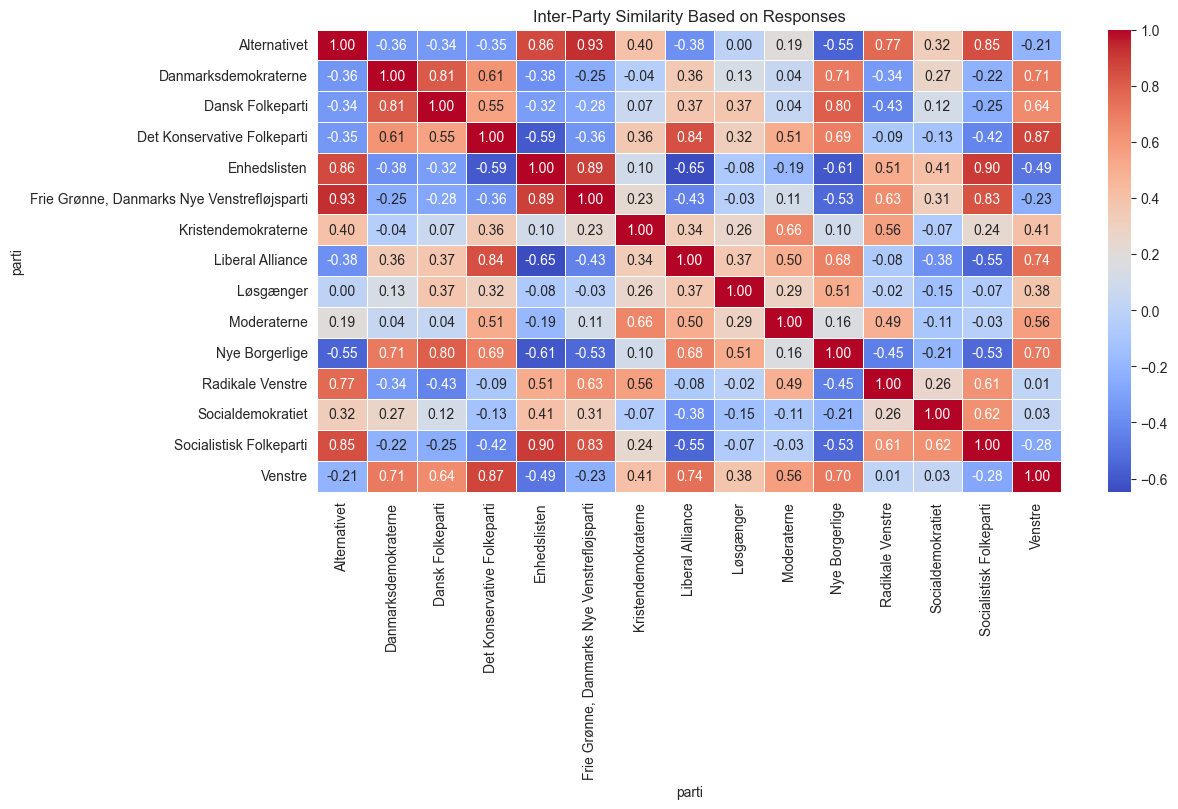

C:\Users\DooMz\AppData\Local\Temp\ipykernel_35892\196012995.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_variability_df, x='Intra-Party Variability', y='Party', palette=party_colors)


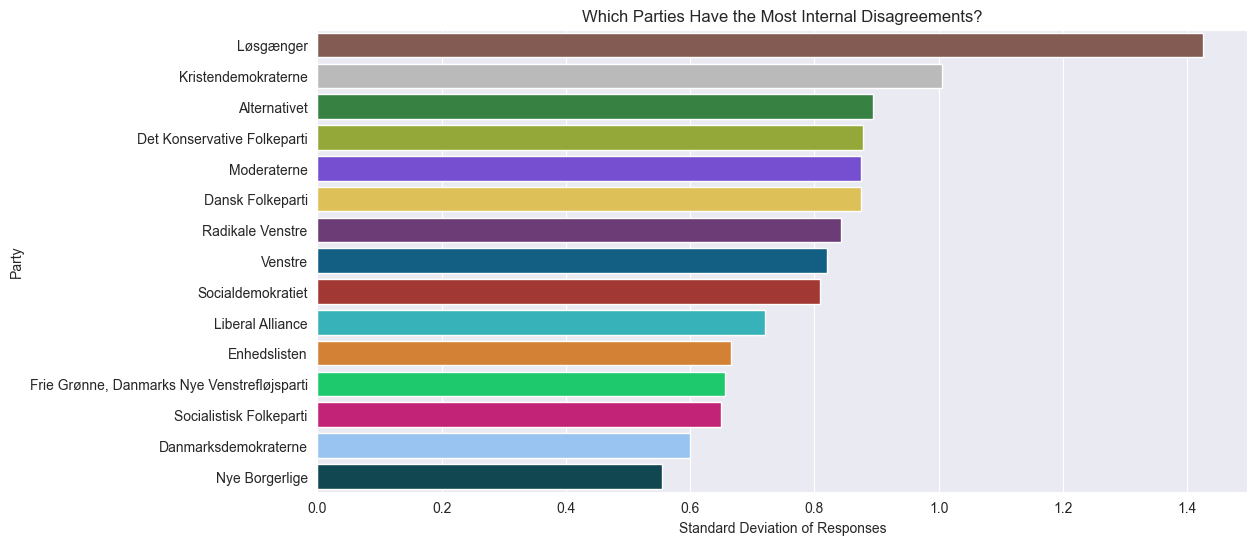


Summary of Internal Disagreements:
                                          Party  Intra-Party Variability
8                                     Løsgænger                 1.425590
6                           Kristendemokraterne                 1.005039
0                                  Alternativet                 0.895038
3                   Det Konservative Folkeparti                 0.877772
9                                   Moderaterne                 0.875390
2                              Dansk Folkeparti                 0.874604
11                             Radikale Venstre                 0.842914
14                                      Venstre                 0.820936
12                            Socialdemokratiet                 0.808726
7                              Liberal Alliance                 0.720309
4                                  Enhedslisten                 0.665378
5   Frie Grønne, Danmarks Nye Venstrefløjsparti                 0.655355
13             

In [37]:
# 📌 Identify response columns (excluding metadata: 'navn' (name), 'parti' (party), and 'alder' (age))
# - This ensures we are only working with numerical responses to survey questions
response_cols = filtered_alldata.drop(columns=['navn', 'parti', 'alder'], errors='ignore').select_dtypes(include=['number']).columns

# 📌 Compute **Intra-Party Variability** (Standard Deviation per Party)
# - Measures how much opinions vary within each political party
# - A higher value means the party members have **more internal disagreements**
intra_party_variability = filtered_alldata.groupby('parti')[response_cols].std().mean(axis=1)

# 📌 Compute **Inter-Party Variability** (Variance of Party Means)
# - Measures how different the average party responses are from each other
# - A higher value means **parties are more ideologically distinct from one another**
party_means = filtered_alldata.groupby('parti')[response_cols].mean()
inter_party_variability = party_means.var(axis=0).mean()

# 📌 Convert intra-party variability to a DataFrame for easier visualization
party_variability_df = pd.DataFrame({
    'Party': intra_party_variability.index,
    'Intra-Party Variability': intra_party_variability.values
}).sort_values(by='Intra-Party Variability', ascending=False)  # Sort parties by internal disagreements

# 📌 Visualization 1: Boxplot - Intra-Party Differences
# - Shows how much opinions vary within each party
plt.figure(figsize=(14, 6))
sns.boxplot(data=filtered_alldata, x='parti', y=filtered_alldata[response_cols].std(axis=1), palette=party_colors)
plt.xticks(rotation=90)  # Rotate party labels for readability
plt.xlabel("Party")  # Label x-axis
plt.ylabel("Response Variability (Standard Deviation)")  # Label y-axis
plt.title("Intra-Party Differences in Responses")  # Title of the plot
plt.show()

# 📌 Visualization 2: Heatmap - Inter-Party Differences
# - Displays how similar or different parties are based on their responses
# - Darker colors indicate more similarity between two parties
plt.figure(figsize=(12, 6))
sns.heatmap(party_means.T.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Inter-Party Similarity Based on Responses")  # Title of the heatmap
plt.show()

# 📌 Visualization 3: Bar Chart - Internal Disagreements
# - Ranks parties by how much disagreement exists within them
plt.figure(figsize=(12, 6))
sns.barplot(data=party_variability_df, x='Intra-Party Variability', y='Party', palette=party_colors)
plt.xlabel("Standard Deviation of Responses")  # Label x-axis
plt.ylabel("Party")  # Label y-axis
plt.title("Which Parties Have the Most Internal Disagreements?")  # Title of the bar chart
plt.show()

# 📌 Explanation of Results
print("\nSummary of Internal Disagreements:")
print(party_variability_df)  # Display the variability data table
print(f"\nOverall inter-party variability (difference between parties): {inter_party_variability:.2f}")  # Print inter-party variability


Comments on Intra-party differences:
The boxplot shows the spread of responses within each party. Parties with high variability (Løsgænger, Kristendemokraterne, Alternativet) indicate internal disagreements among candidates. Løsgænger is not a political party, but contains candidates which have no party, which explains the high variability.
Parties with lower variability (Danmarksdemokraterne, Nye borgerlige) indicate a more ideological alignment and less disagreements among candidates.

Comments on Inter-party similarity:
The heatmap shows how similar parties are, based on their responses, where dark red indicates high similarity and dark blue suggests opposing positions. 
As for the political accuracy, it is hard for me to comment on, as I am not as politically informed as the task probably requires. I can say that there seems to be a tendency that right-wing parties have higher similarity to other right-wing parties, and the same for left-wing parties being more similar to other left-wing parties, which makes sense, in my head at least.

Model Accuracy Scores:
                       Accuracy
Decision Tree          0.711765
Random Forest          0.935294
Gradient Boosted Tree  0.911765

Candidates Who Might Be in the Wrong Party:
                          navn  alder                                 Actual Party              Predicted Party
680  Regitze Harslund Sancoeur     23                  Det Konservative Folkeparti                      Venstre
42                  Ali Khatib     27  Frie Grønne, Danmarks Nye Venstrefløjsparti                 Alternativet
763         Niels Martin Viuff     62                  Det Konservative Folkeparti                      Venstre
336          Niels Bjarne Lund     65                                 Enhedslisten      Socialistisk Folkeparti
827         Jørgen Mathow-Juhl     56                             Liberal Alliance  Det Konservative Folkeparti
333                Henrik Boye     66                                 Alternativet                 Enhedslisten
615        Anders Ma

<Figure size 800x600 with 0 Axes>

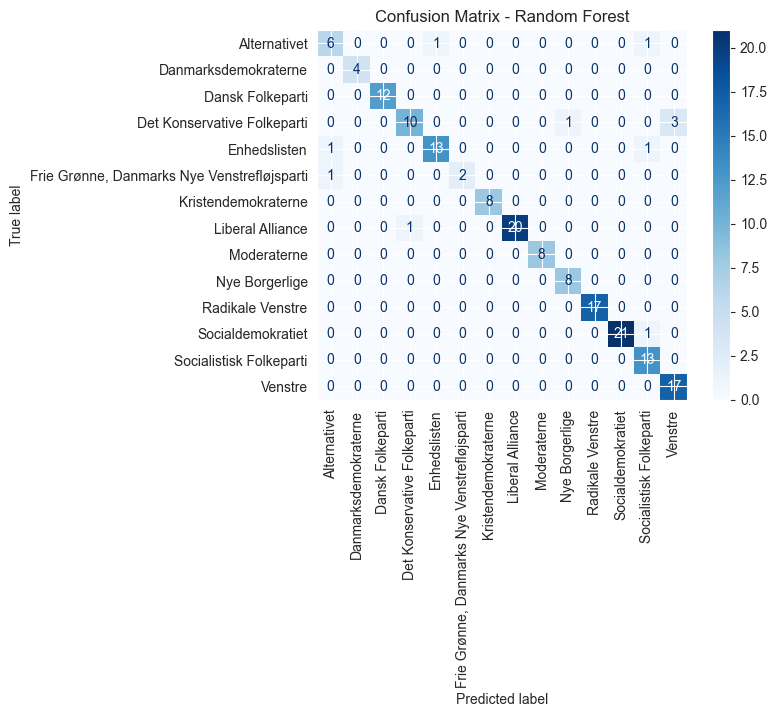

Random forest f1 score:
0.9342979919603623


In [38]:
# 📌 Load dataset from an Excel file
file_path = "alldata.xlsx"  # Update the file path if needed
alldata = pd.read_excel(file_path)

# 📌 Remove candidates younger than 18 (ensuring valid age for political candidates)
filtered_alldata = alldata[alldata['alder'] > 17].copy()

# 📌 Remove "Løsgænger" (independent candidates) since they have no official party
filtered_alldata_without_loesgaenger = filtered_alldata[filtered_alldata['parti'] != "Løsgænger"].copy()

# 📌 Identify response columns (Exclude metadata: 'navn' (name), 'parti' (party), 'alder' (age))
# - We only keep numerical response columns used as input features
response_cols = filtered_alldata_without_loesgaenger.drop(columns=['navn', 'parti', 'alder'], errors='ignore').select_dtypes(include=['number']).columns

# 📌 Prepare data for modeling
X = filtered_alldata_without_loesgaenger[response_cols]  # Features (responses to survey questions)
y = filtered_alldata_without_loesgaenger['parti']  # Target variable (party affiliation)

# 📌 Encode target variable (Convert party names into numerical labels)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 📌 Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 📌 Define machine learning models for classification
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),  # Simple decision tree
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),  # Stronger ensemble model
    "Gradient Boosted Tree": GradientBoostingClassifier(random_state=42, n_estimators=100)  # Advanced ensemble model
}

# 📌 Train and evaluate models
model_results = {}

for name, model in models.items():
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Compute accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    
    # Get unique classes in test set (to avoid label mismatches)
    unique_classes = np.unique(y_test)
    target_names = label_encoder.inverse_transform(unique_classes)  # Convert back to party names
    
    # Store results including accuracy, classification report, and predictions
    model_results[name] = {
        "Accuracy": accuracy,
        "Report": classification_report(y_test, y_pred, labels=unique_classes, target_names=target_names, output_dict=True),
        "Predictions": y_pred
    }

# 📌 Convert accuracy scores to DataFrame for display
accuracy_df = pd.DataFrame({k: v["Accuracy"] for k, v in model_results.items()}, index=["Accuracy"]).T

# 📌 Print model accuracy results
print("Model Accuracy Scores:")
print(accuracy_df)

# 📌 Identify misclassified candidates using the Random Forest model (best performer)
y_test_actual = label_encoder.inverse_transform(y_test)  # Convert true labels to original party names
y_test_pred = label_encoder.inverse_transform(model_results["Random Forest"]["Predictions"])  # Convert predicted labels to party names

# 📌 Create a DataFrame of misclassified candidates using X_test index
misclassified = filtered_alldata_without_loesgaenger.loc[X_test.index].copy()  # Retrieve candidate details
misclassified['Actual Party'] = y_test_actual
misclassified['Predicted Party'] = y_test_pred

# 📌 Filter out only misclassified candidates
wrong_party_candidates = misclassified[misclassified['Actual Party'] != misclassified['Predicted Party']]

# 📌 Display misclassified candidates
print("\nCandidates Who Might Be in the Wrong Party:")
print(wrong_party_candidates[['navn', 'alder', 'Actual Party', 'Predicted Party']])

# 📌 🔍 Visualization: Confusion Matrix for Best Model (Random Forest)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, model_results["Random Forest"]["Predictions"], labels=unique_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues", values_format="d")

# 📌 Rotate x-axis labels to make party names more readable
plt.xticks(rotation=90)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# 📌 Calculate F1 score for the Random Forest model
f1 = f1_score(y_test, model_results["Random Forest"]["Predictions"], average="weighted")

# 📌 Display the F1 score for model evaluation
print("Random forest f1 score:")
print(f1)


Comments on the classification models:
Random Forest reached the highest accuracy being 93,5%, and with a f1 score of almost the same: 93,4% which indicates that the model is very good at predicting the candidates parties.
We can take a look at the misclassifications, where the candidates answers maybe align better with another party than their own. The party of a candidate is probably more nuanced than just the answers to these questions, so saying a candidate is member of the wrong party based on this model would be extreme. 

For fun, we can also feed the løsgænger candidates into the model, and see which party it predicts for them:

In [39]:
# Extract Løsgænger candidates from the original dataset
loesgaenger_candidates = filtered_alldata[filtered_alldata['parti'] == "Løsgænger"].copy()

# Prepare their data (use only the same response columns as in training)
X_loesgaenger = loesgaenger_candidates[response_cols]

# Use the trained Random Forest model to predict their party
y_loesgaenger_pred = models["Random Forest"].predict(X_loesgaenger)

# Convert predictions back to party names
loesgaenger_candidates["Predicted Party"] = label_encoder.inverse_transform(y_loesgaenger_pred)

# Display the results (show their name, age, and predicted party)
print("\nLøsgænger Candidates and Their Predicted Party:")
print(loesgaenger_candidates[['navn', 'alder', 'Predicted Party']])



Løsgænger Candidates and Their Predicted Party:
                  navn  alder   Predicted Party
4       Tom Gillesberg     58      Enhedslisten
8    Chresten H. Ibsen     46  Radikale Venstre
601     Rasmus Paludan     40    Nye Borgerlige


Now we know where we should watch for Rasmus Paludans ramblings next ;)